In [ ]:
from FIT_python.plot_style import apply_style
apply_style()



📥 Schritt 1: Datenimport & Cleaning
[REPORT] cleaned Aj_Someringii: shape=(370, 141)
[REPORT] cleaned Amur_Tiger: shape=(605, 133)
[REPORT] cleaned Bengal_tiger: shape=(586, 133)
[REPORT] cleaned cheetah: shape=(781, 141)
[REPORT] cleaned Eurasian_Otter: shape=(628, 214)
[REPORT] cleaned Giant_Panda: shape=(523, 129)
[REPORT] cleaned Jubatus: shape=(566, 141)
[REPORT] cleaned Lowlandtapir: shape=(426, 126)
[REPORT] cleaned Mountain_Lion: shape=(535, 138)
[REPORT] cleaned White_Rhino: shape=(1273, 117)
[SUCCESS] clean_all completed.

✂️ Schritt 2: Splitting & Fold-Zuordnung
✅ Fold-Methode verwendet: stratified_group
Fold
0     98
1    112
2     90

📊 aj_someringii – train – 300 Zeilen | 20 Individuen | 43 Trails
sex
m    153
f    147

📊 aj_someringii – test – 70 Zeilen | 5 Individuen | 10 Trails
sex
f    42
m    28

📊 aj_someringii – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ aj_someringii gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0

C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df["Fold"] = fold_ids
C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\src\FIT_python\data_split_and_summary\split_utils.py:213: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  train_df["Fold"] = fold_ids



📊 eurasian_otter – train – 395 Zeilen | 27 Individuen | 54 Trails
sex
f    220
m    175

📊 eurasian_otter – test – 152 Zeilen | 14 Individuen | 19 Trails
sex
f    86
m    66

📊 eurasian_otter – inference – 81 Zeilen | 1 Individuen | 8 Trails
sex
unknown    81

✅ eurasian_otter gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0     88
1    144
2    172

📊 giant_panda – train – 404 Zeilen | 33 Individuen | 61 Trails
sex
f    238
m    166

📊 giant_panda – test – 119 Zeilen | 9 Individuen | 16 Trails
sex
f    63
m    56

📊 giant_panda – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ giant_panda gespeichert (csv & parquet)
✅ Fold-Methode verwendet: stratified_group
Fold
0    153
1    147
2    147

📊 jubatus – train – 447 Zeilen | 32 Individuen | 64 Trails
sex
f    258
m    189

📊 jubatus – test – 119 Zeilen | 8 Individuen | 17 Trails
sex
f    70
m    49

📊 jubatus – inference – 0 Zeilen | 0 Individuen | 0 Trails
Series([], )

✅ jubatus gespeichert

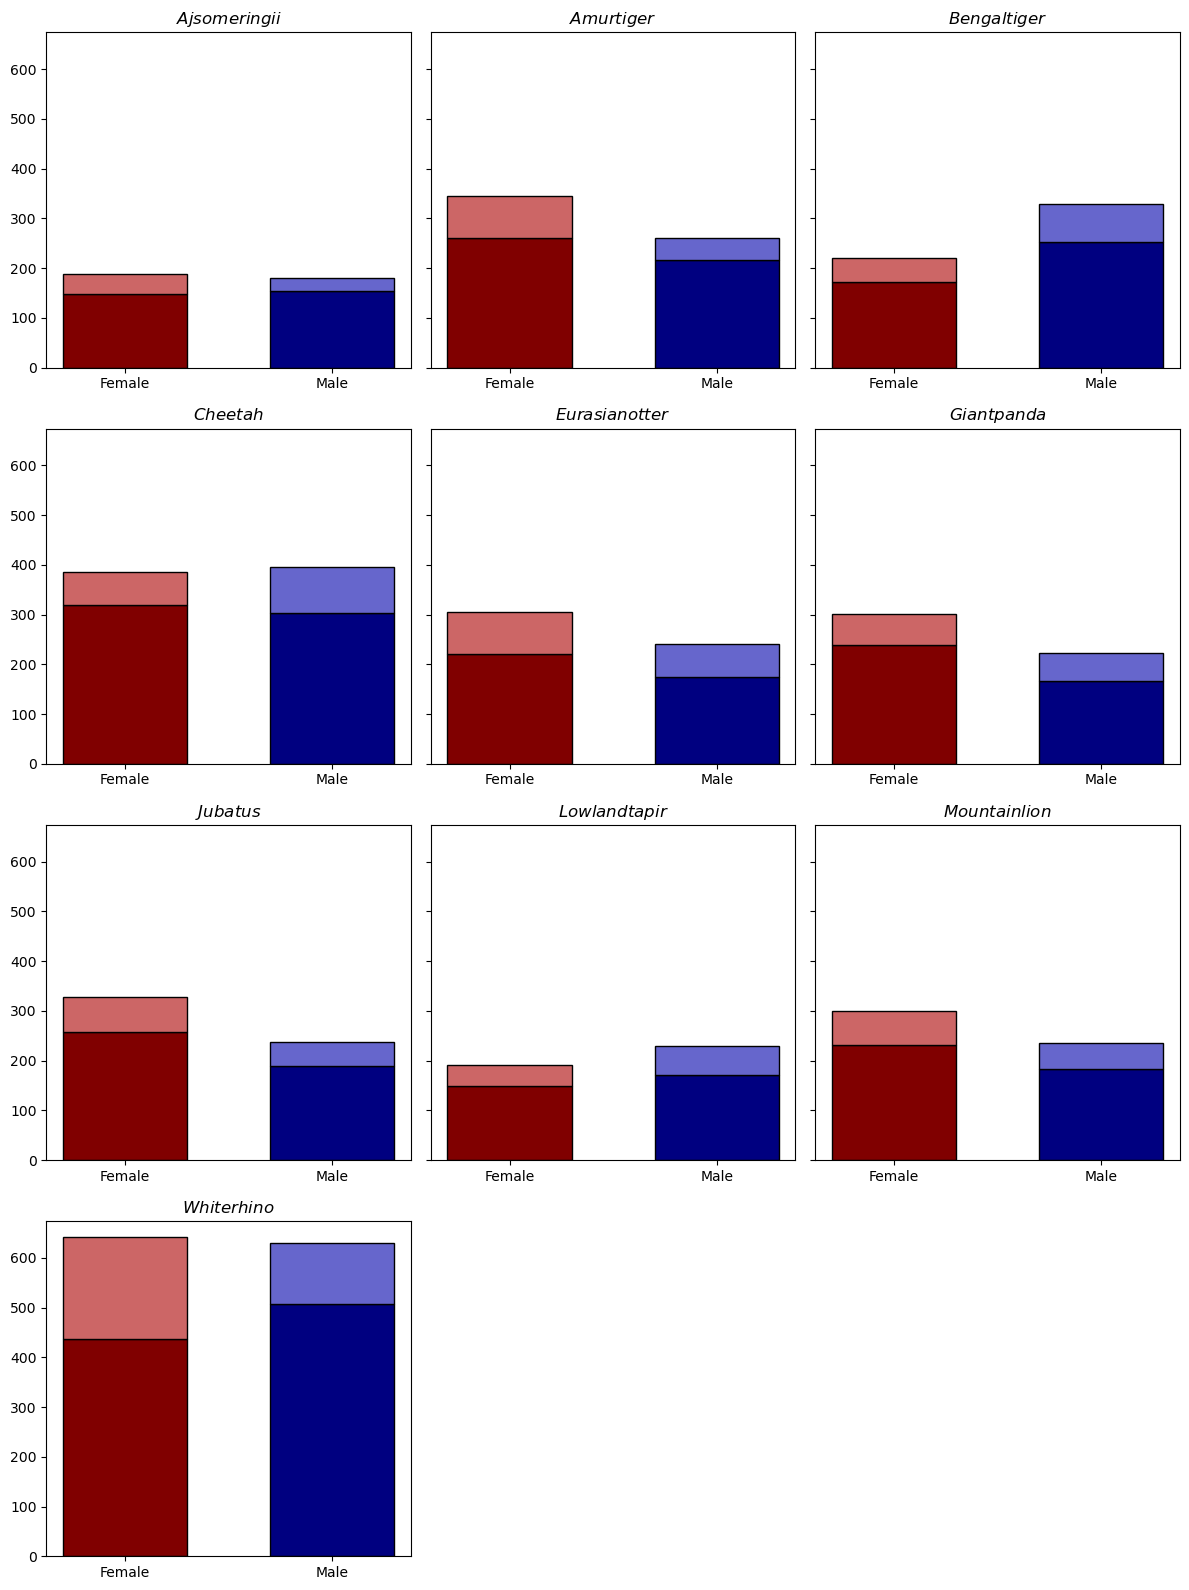

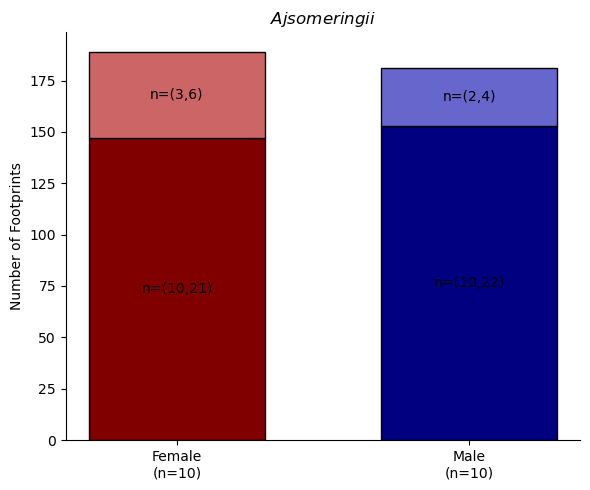

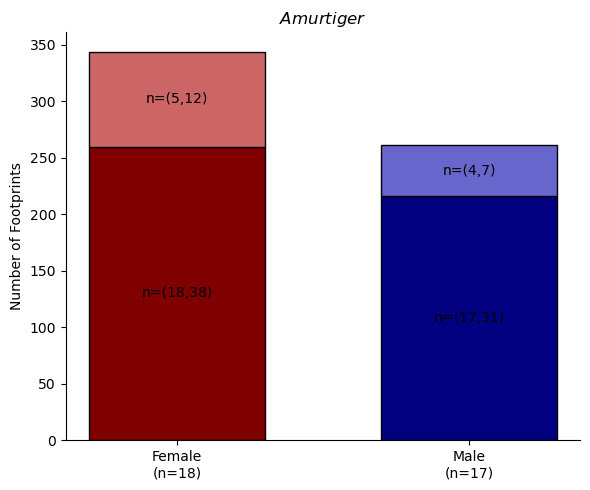

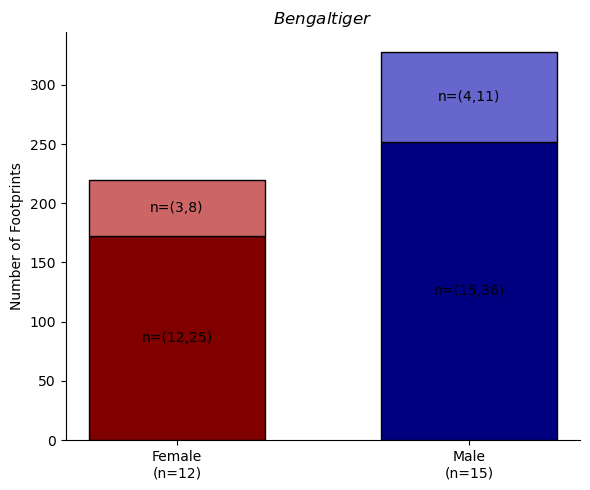

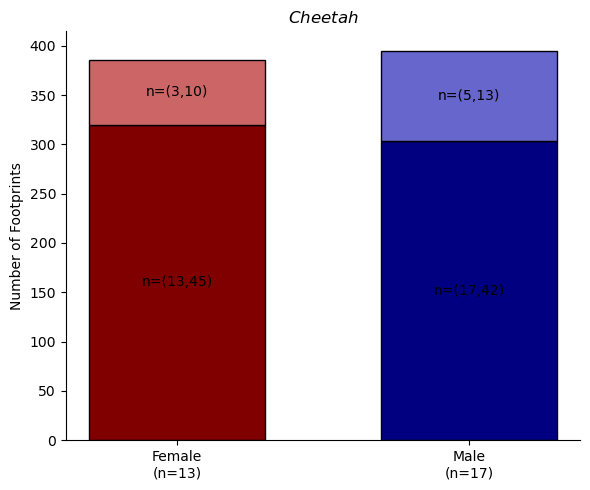

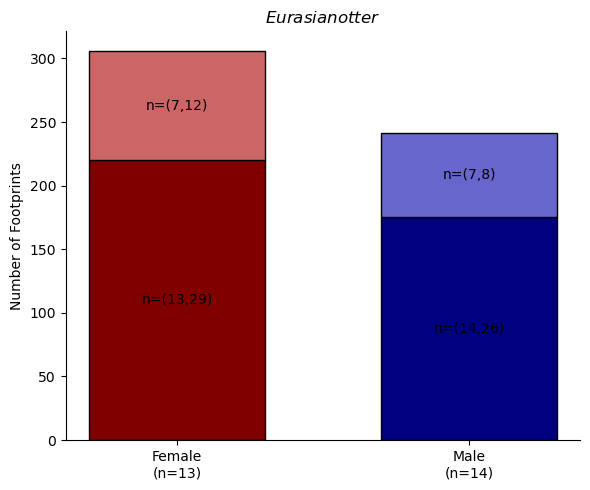

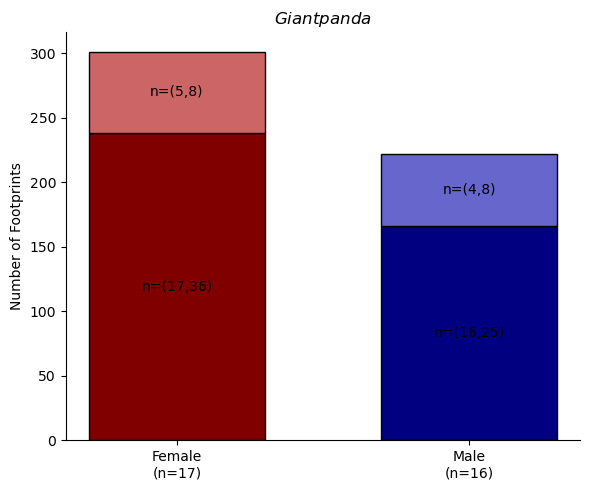

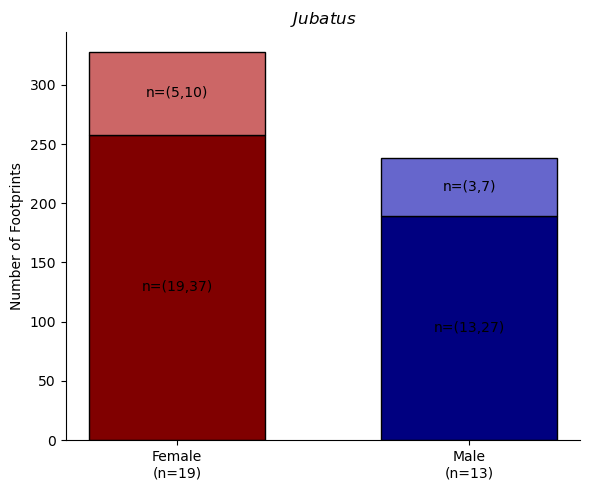

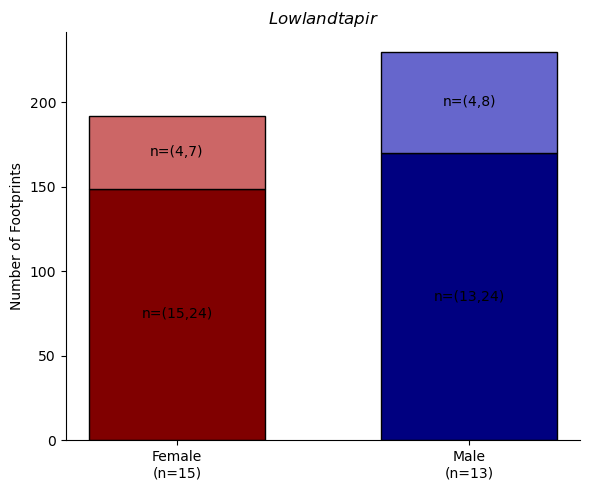

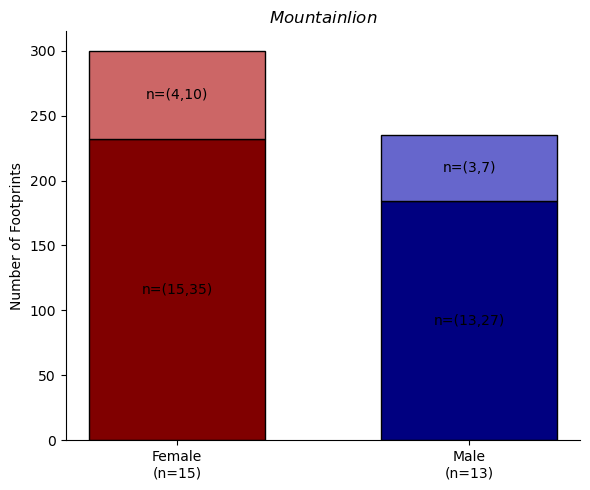

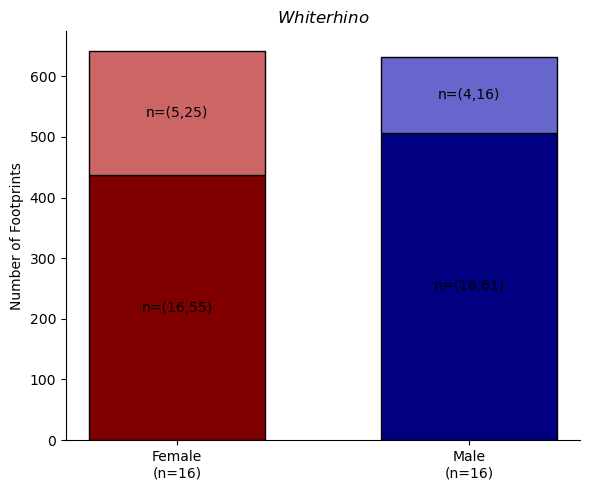

In [1]:
# %% [code]
from pathlib import Path
import pandas as pd
import numpy as np
import ast
from tqdm.auto import tqdm
from joblib import Parallel, delayed
from sklearn.model_selection import ParameterSampler

from FIT_python.pipeline_sex.pipeline_wrapper_sex import PipelineWrapper
from FIT_python.config import RESULTS_DATA_DIR

# 1) Prepare (Clean → Split → Summary)
prep = PipelineWrapper(
    model_keys=["log_reg"],  # Dummy
    impute_method=None,
    outlier_method=None,
    scaler_method=None,
    reduce_pre_method=None,
    reduce_post_method=None,
    fs_method=None,
    fs_k=None,
)
prep.prepare()



In [2]:
import shutil
from FIT_python.pipeline_sex.pipeline_wrapper_sex import _cache_dir

# Cache-Verzeichnis komplett entfernen
shutil.rmtree(_cache_dir)
print(f"Cache gelöscht: {_cache_dir}")


Cache gelöscht: C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\pipeline_cache


In [ ]:
# %% [code] RandomizedGridSearchCV mit Standard-Metriken & Custom-Auswertung (aggregiert)
from pathlib import Path
import pandas as pd
import numpy as np
from sklearn.model_selection import RandomizedSearchCV
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from tqdm.auto import tqdm
from tqdm_joblib import tqdm_joblib
import joblib
from functools import reduce
import operator

from sklearn.metrics import accuracy_score, balanced_accuracy_score
from FIT_python.pipeline_sex.transform_wrapper                import NumericTransformer
from FIT_python.pipeline_sex.feature_selection_wrapper        import FeatureSelectionTransformer
from FIT_python.pipeline_sex.outlier_wrapper                  import OutlierCleanerTransformer
from FIT_python.pipeline_sex.feature_scaler_wrapper           import FeatureScalerTransformer
from FIT_python.pipeline_sex.dimensionality_reduction_wrapper import DimensionalityReducerTransformer
from FIT_python.pipeline_sex.models                           import MODELS
from FIT_python.pipeline_sex.grouped_metrics                  import individual_accuracies, individual_majority_stats
from FIT_python.config                                        import SPLITS_DIR, RESULTS_DATA_DIR

import warnings
from sklearn.exceptions import ConvergenceWarning

# Warnings nur einmal
warnings.filterwarnings("once", category=ConvergenceWarning, message="Objective did not converge.*")
warnings.filterwarnings("once", category=UserWarning,       message="X does not have valid feature names.*")

# 1) Modell‐Keys
model_keys = [
    "logreg_l2","logreg_l1",
    "rf_small","rf_med","rf_large",
    "knn_3","knn_5","knn_7",
    "svm_linear","svm_rbf",
    "xgb_std","xgb_hist",
    "lgbm_std","lgbm_md10",
    "lda",
]

# 2) Param‐Räume (inkl. PCA/UMAP‐ & Outlier‐Hyperparams)
param_distributions = {
    # Feature Selection (inkl. RF)
    "select__method":          [None, "forward", "lasso", "variance", "random_forest"],
    "select__k":               [1,2,3,4,5,6,10, 20, 50,100],

    # --- nachher ---
    "outlier__method":         [None, "clip"],
    "outlier__lower_quantile": [0.01, 0.05],
    "outlier__upper_quantile": [0.90, 0.95],

    # Scaling
    "scale__method":           [None, "standard", "robust", "minmax"],

    # DimRed Pre
    "reduce_pre__method":        [None, "pca", "umap"],
    "reduce_pre__n_components":  [2, 10],
    "reduce_pre__n_neighbors":   [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_pre__min_dist":      [0.1, 0.5],
    "reduce_pre__whiten":        [False, True],

    # DimRed Post
    "reduce_post__method":       [None, "pca", "umap"],
    "reduce_post__n_components": [2, 10],
    "reduce_post__n_neighbors":  [5, 10, 15, 30, 50],   # ← mehr Nachbarn
    "reduce_post__min_dist":     [0.1, 0.5],
    "reduce_post__whiten":       [False, True],

    # Classifier
    "clf": [MODELS[k] for k in model_keys],
}

# 3) Wie groß ist der Suchraum?
lengths = {k: len(v) for k,v in param_distributions.items()}
total_combinations = reduce(operator.mul, lengths.values(), 1)

print("Anzahl der Werte pro Parameter:")
for k, l in lengths.items():
    print(f"  {k:25s}: {l}")
print(f"\n→ Gesamtzahl aller Hyper‐Kombinationen: {total_combinations:,}")


# 3) Ergebnis-Ordner
base_dir = Path(RESULTS_DATA_DIR) / "random_search_standard_metrics"
base_dir.mkdir(parents=True, exist_ok=True)

# Unterordner für Best-Modelle je Metrik
metrics = [
    "maj_test_pct",
    "balanced_test_acc",      # <-- hier
    "accuracy_test",
    "mean_test_neg_log_loss"
]
for m in metrics:
    (base_dir / f"best_{m}").mkdir(exist_ok=True)

# 4) Scoring-Dict
scoring = {
    "accuracy":          "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "neg_log_loss":      "neg_log_loss",
}

pipeline_order = [
    "outlier__method", "outlier__lower_quantile", "outlier__upper_quantile",
    "scale__method", "select__method", "select__k",
    "reduce_pre__method", "reduce_pre__n_components", "reduce_pre__n_neighbors", "reduce_pre__min_dist", "reduce_pre__whiten",
    "reduce_post__method", "reduce_post__n_components", "reduce_post__n_neighbors", "reduce_post__min_dist", "reduce_post__whiten",
    "clf"
]


# 5) Sammel-Listen
raw_records  = []
best_records = []

# 6) Loop über Spezies
for species_dir in tqdm(sorted(Path(SPLITS_DIR).iterdir()), desc="Species"):
    if not species_dir.is_dir(): 
        continue
    species = species_dir.name
    print(f"\n🔄 Processing species: {species}")

    # 6.1) Train/Test laden & Fold entfernen
    df_train = (pd.read_parquet(species_dir / "train.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))
    df_test  = (pd.read_parquet(species_dir / "test.parquet")
                  .query("sex in ['f','m']")
                  .drop(columns=["Fold"], errors="ignore"))

    # 🔍 Feature-Spalten abhängig von Spezies auswählen
    if species == "eurasian_otter":
        feature_cols = [
            c for c in df_train.columns 
            if c.startswith(("dist", "ang", "t")) and pd.api.types.is_numeric_dtype(df_train[c])
        ]
    else:
        feature_cols = [
            c for c in df_train.columns[5:] 
            if pd.api.types.is_numeric_dtype(df_train[c])
        ]
    print(f"  → {len(feature_cols)} numerische Features")

    # 6.2) Features, Ziel & IDs
    X_tr, y_tr, ids_tr = (
        df_train[feature_cols],
        df_train["sex"].map({"f":0,"m":1}).values,
        df_train["individual_id"].values
    )
    X_te, y_te, ids_te = (
        df_test[feature_cols],
        df_test["sex"].map({"f":0,"m":1}).values,
        df_test["individual_id"].values
    )

    # 6.3) Pipeline
    steps = [
        ("transform",   NumericTransformer()),                                   # 1) Grund-Transformationen
        ("outlier",     OutlierCleanerTransformer(method="clip")),               # 2) Ausreißer entfernen
        ("scale",       FeatureScalerTransformer(method="standard")),            # 3) Skalierung
        ("select",      FeatureSelectionTransformer(method="forward", k=1)),     # 4) Feature-Selektion
        ("reduce_pre",  DimensionalityReducerTransformer(method=None, n_components=1)),  # 5) erste Dimensionstahlung
        ("reduce_post", DimensionalityReducerTransformer(method=None, n_components=1)),  # 6) zweite Dimensionstahlung (z. B. Visualisierung)
        ("clf",         MODELS["rf_small"]),                                     # 7) Klassifikator
    ]
    pipe = Pipeline(steps)

    # 6.4) RandomizedSearchCV
    search = RandomizedSearchCV(
        estimator=pipe,
        param_distributions=param_distributions,
        n_iter=1000,      # kleiner Testdurchgang
        scoring=scoring,
        refit=False,
        cv=5,
        n_jobs=-1,
        random_state=42,
        verbose=1,
    )

# 6.5) Fit mit tqdm (dynamisch berechnete Gesamt-Anzahl an Fits)
    n_iter = search.n_iter
    # wenn cv ein Integer ist, nutzen wir es direkt, sonst versuchen wir n_splits zu lesen
    folds  = search.cv if isinstance(search.cv, int) else getattr(search.cv, "n_splits", len(list(search.cv)))
    total_fits = n_iter * folds

    with tqdm_joblib(tqdm(desc=f"{species} RS-CV", total=total_fits, leave=False)):
        search.fit(X_tr, y_tr)

    # 6.6) CV-Ergebnisse & Custom-Metriken sammeln
    cv_res = search.cv_results_
    for i, params in enumerate(cv_res["params"]):
        record = {
            "species":                     species,
            "mean_test_accuracy":          cv_res["mean_test_accuracy"][i],
            "mean_test_balanced_accuracy": cv_res["mean_test_balanced_accuracy"][i],
            "mean_test_neg_log_loss":      cv_res["mean_test_neg_log_loss"][i],
            **params
        }
        # kompletter Re-Fit für Custom-Metriken
        mdl = clone(pipe).set_params(**params).fit(X_tr, y_tr)
        y_tr_pred = mdl.predict(X_tr)
        y_te_pred = mdl.predict(X_te)
        y_all_true = np.concatenate([y_tr, y_te])
        y_all_pred = np.concatenate([y_tr_pred, y_te_pred])
        ids_all     = np.concatenate([ids_tr, ids_te])

        fem_tr, mal_tr, bal_tr    = individual_accuracies(y_tr, y_tr_pred, ids_tr)
        fem_te, mal_te, bal_te    = individual_accuracies(y_te, y_te_pred, ids_te)
        ct_tr, wr_tr, pct_tr      = individual_majority_stats(y_tr, y_tr_pred, ids_tr)
        ct_te, wr_te, pct_te      = individual_majority_stats(y_te, y_te_pred, ids_te)
        fem_all, mal_all, bal_all = individual_accuracies(y_all_true, y_all_pred, ids_all)
        ct_all, wr_all, pct_all   = individual_majority_stats(y_all_true, y_all_pred, ids_all)
                # Accuracy & Balanced Accuracy
        acc_tr  = accuracy_score(y_tr,  y_tr_pred)
        bal_tr  = balanced_accuracy_score(y_tr,  y_tr_pred)
        acc_te  = accuracy_score(y_te,  y_te_pred)
        bal_te  = balanced_accuracy_score(y_te,  y_te_pred)

        # Neu: Full-Dataset Accuracy & Balanced Accuracy
        acc_all = accuracy_score(y_all_true, y_all_pred)
        bal_all = balanced_accuracy_score(y_all_true, y_all_pred)

        

        record.update({
            "female_train_acc":   fem_tr, "male_train_acc":   mal_tr, "balanced_train_acc": bal_tr, "accuracy_train":          acc_tr,
            "female_test_acc":    fem_te, "male_test_acc":    mal_te, "balanced_test_acc":  bal_te, "accuracy_test":          acc_te,
            "female_full_acc":    fem_all,"male_full_acc":    mal_all,"balanced_full_acc":  bal_all,"accuracy_full":          acc_all,
            "maj_train_count":    ct_tr, "maj_train_wrong":  wr_tr, "maj_train_pct":      pct_tr,
            "maj_test_count":     ct_te, "maj_test_wrong":   wr_te, "maj_test_pct":       pct_te,
            "maj_full_count":     ct_all,"maj_full_wrong":   wr_all,"maj_full_pct":       pct_all,
        })
        
        # 1) pipeline_id bauen
        pid_parts = []
        for key in pipeline_order:
            val = params.get(key)
            pid_parts.append(f"{key}={val if val is not None else 'None'}")
        record["pipeline_id"] = ";".join(pid_parts)

        # 2) Alle NaNs in "None" umwandeln
        for k, v in record.items():
            if pd.isna(v):
                record[k] = "None"
        raw_records.append(record)

# 6.7) Beste Modelle je Metrik speichern UND Joblib dump
    df_eval = pd.DataFrame([r for r in raw_records if r["species"] == species])
    for metric in metrics:
        # Index und Parameter des besten Runs finden
        best_idx    = df_eval[metric].idxmax()
        best_params = cv_res["params"][best_idx]
        # Erstelle das Record-Dict für best_records
        best_record = df_eval.loc[best_idx].to_dict()
        best_record["best_metric"] = metric

        # Finales Modell trainieren und speichern
        best_pipe = clone(pipe).set_params(**best_params).fit(X_tr, y_tr)
        out_path = base_dir / f"best_{metric}" / f"{species}.joblib"
        joblib.dump(best_pipe, out_path)
        print(f"✅ Modell für Spezies '{species}', Kriterium '{metric}' gespeichert unter:\n   {out_path}")

        # **Ganz wichtig**: best_record in best_records einfuegen
        best_records.append(best_record)

    # → CSVs direkt aktualisieren (innerhalb des Species-Loops)
    all_csv  = base_dir / "all_results.csv"
    best_csv = base_dir / "best_models.csv"
    # DataFrames bauen und alle NaNs in "None" umwandeln
    df_all  = pd.DataFrame(raw_records).fillna("None")
    df_best = pd.DataFrame(best_records).fillna("None")

    # CSVs speichern
    df_all.to_csv(all_csv,  index=False)
    df_best.to_csv(best_csv, index=False)



Anzahl der Werte pro Parameter:
  select__method           : 5
  select__k                : 10
  outlier__method          : 2
  outlier__lower_quantile  : 2
  outlier__upper_quantile  : 2
  scale__method            : 4
  reduce_pre__method       : 3
  reduce_pre__n_components : 2
  reduce_pre__n_neighbors  : 5
  reduce_pre__min_dist     : 2
  reduce_pre__whiten       : 2
  reduce_post__method      : 3
  reduce_post__n_components: 2
  reduce_post__n_neighbors : 5
  reduce_post__min_dist    : 2
  reduce_post__whiten      : 2
  clf                      : 15

→ Gesamtzahl aller Hyper‐Kombinationen: 345,600,000


Species:   0%|          | 0/10 [00:00<?, ?it/s]


🔄 Processing species: aj_someringii
  → 136 numerische Features


aj_someringii RS-CV:   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/5000 [00:00<?, ?it/s]

Fitting 5 folds for each of 1000 candidates, totalling 5000 fits


In [ ]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

# 1) Pfade definieren
csv_path    = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\results\data\random_search_standard_metrics\all_results.csv"
output_dir  = r"C:\Users\Frede\OneDrive\Projects and Disschaptors\FIT_package\tests\results\data\random_search_standard_metrics\results_plots"
os.makedirs(output_dir, exist_ok=True)

# 2) Daten einlesen
df = pd.read_csv(csv_path)

# 3) Heatmap-Funktion mit einheitlichem Farbschema
def plot_heatmap(metric, cmap="Blues", low_color="red", high_color="yellow"):
    # Pivot-Tabelle
    heat = df.pivot_table(
        index="pipeline_id",
        columns="species",
        values=metric,
        aggfunc="mean"
    )
    # all_species-Spalte und Sortierung
    heat["all_species"] = heat.mean(axis=1)
    heat = heat.sort_values(by="all_species", ascending=False)

    # Plot
    plt.figure(figsize=(14, 12))
    ax = sns.heatmap(
        heat,
        annot=True, fmt=".3f",
        cmap=cmap,
        linewidths=0.3, linecolor="gray",
        yticklabels=False
    )
    plt.ylabel("")
    plt.xlabel("Species")
    title = {
        "balanced_test_acc": "Balanced Test Accuracy (roh)",
        "maj_test_pct":      "Majority Test Percentage (roh)"
    }.get(metric, metric)
    plt.title(f"{title} per Pipeline & Species\nmit {cmap}-Farbverlauf")
    plt.xticks(rotation=45, ha="right")

    # Min in low_color, Max in high_color einrahmen
    for j, col in enumerate(heat.columns):
        vals = heat[col].astype(float)
        # niedrigster Wert
        i_min     = vals.idxmin()
        i_min_idx = heat.index.get_loc(i_min)
        ax.add_patch(Rectangle((j, i_min_idx), 1, 1, fill=False, edgecolor=low_color,  lw=2))
        # höchster Wert
        i_max     = vals.idxmax()
        i_max_idx = heat.index.get_loc(i_max)
        ax.add_patch(Rectangle((j, i_max_idx), 1, 1, fill=False, edgecolor=high_color, lw=2))

    plt.tight_layout()
    out_path = os.path.join(output_dir, f"heatmap_{metric}.png")
    plt.savefig(out_path, dpi=150)
    plt.show()
    print(f"Heatmap für '{metric}' gespeichert unter: {out_path}\n")

# 4) Zwei Heatmaps mit demselben Farbschema
plot_heatmap("balanced_test_acc", cmap="Blues", low_color="red",    high_color="yellow")
plot_heatmap("maj_test_pct",      cmap="Blues", low_color="red",    high_color="yellow")
